## Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the cleaned credit scoring dataset.  
The objective is to understand variable distributions, identify outliers, inspect class imbalance, and analyze how different applicant attributes influence loan approval.

### Loading the Cleaned Dataset

The cleaned dataset from the preprocessing stage is loaded to begin analytical exploration.  
This ensures that all observations are based on validated and cleaned records.
import all the required libraries 

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv("cleaned_loan_data.csv")

### Dataset Structure Inspection

The size, columns, and data types of the dataset are reviewed to understand the analytical space before visualization.

In [4]:
print(df.shape)
print(df.info())

(4969, 10)
<class 'pandas.DataFrame'>
RangeIndex: 4969 entries, 0 to 4968
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              4969 non-null   int64  
 1   Income           4969 non-null   float64
 2   LoanAmount       4969 non-null   float64
 3   CreditScore      4969 non-null   float64
 4   YearsExperience  4969 non-null   int64  
 5   Gender           4969 non-null   str    
 6   Education        4969 non-null   str    
 7   City             4969 non-null   str    
 8   EmploymentType   4969 non-null   str    
 9   LoanApproved     4969 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 542.1 KB
None


### Loan Approval Class Distribution

The target variable `LoanApproved` is examined to determine whether the number of approved and non-approved applications is balanced.

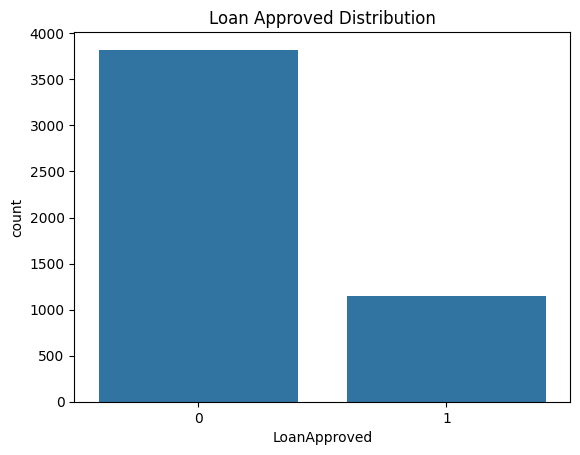

In [16]:
sns.countplot(x=df['LoanApproved'])
plt.title("Loan Approved Distribution")
plt.show()

### Percentage Analysis of Loan Approval Classes

The percentage contribution of each class is calculated to measure the severity of class imbalance.

In [17]:
(df['LoanApproved'].value_counts(normalize=True) * 100).round(2)

LoanApproved
0    76.92
1    23.08
Name: proportion, dtype: float64

### Distribution of Numerical Features

Histograms are plotted for all major numerical variables to understand their spread, concentration, and skewness.

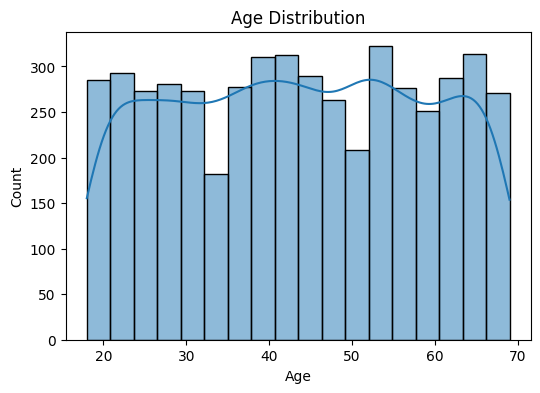

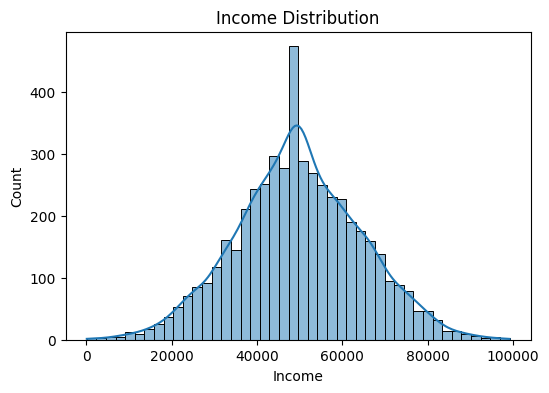

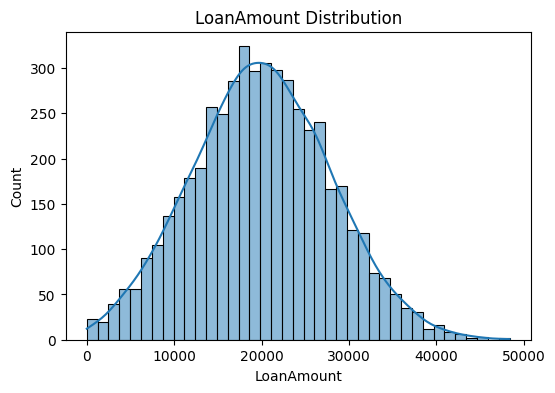

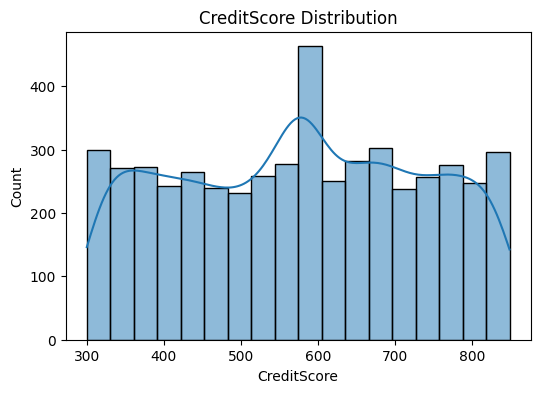

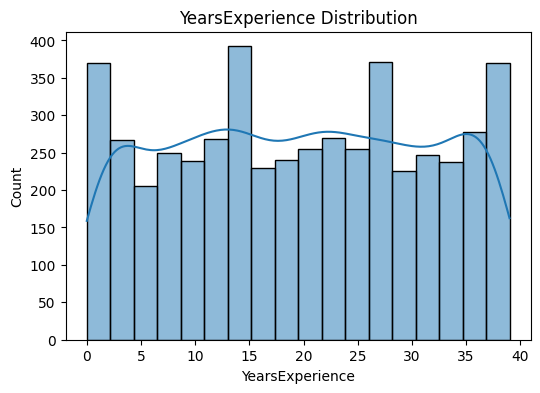

In [18]:
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

### Outlier Detection in Numerical Variables

Boxplots are used to visually inspect extreme values and outliers in the numerical features.

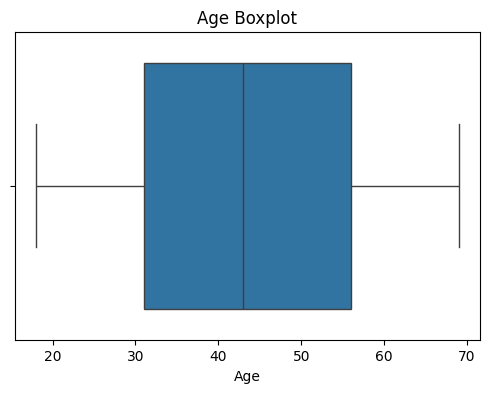

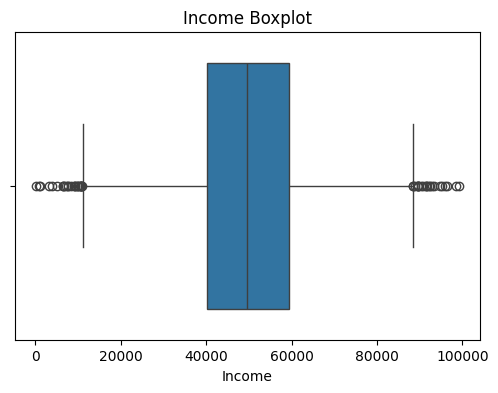

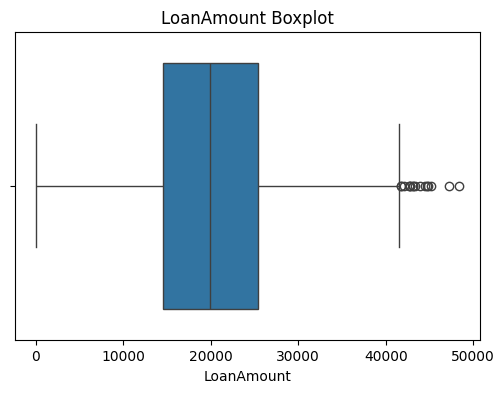

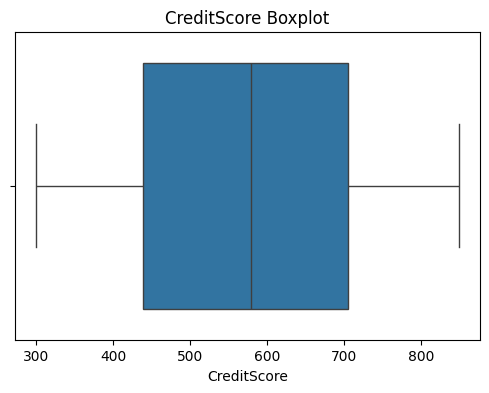

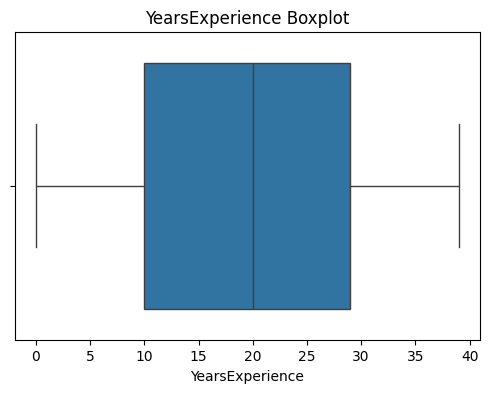

In [19]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()

### Numerical Feature Relationship with Loan Approval

Boxplots are used to compare the distribution of key financial attributes across approved and non-approved loan applications.

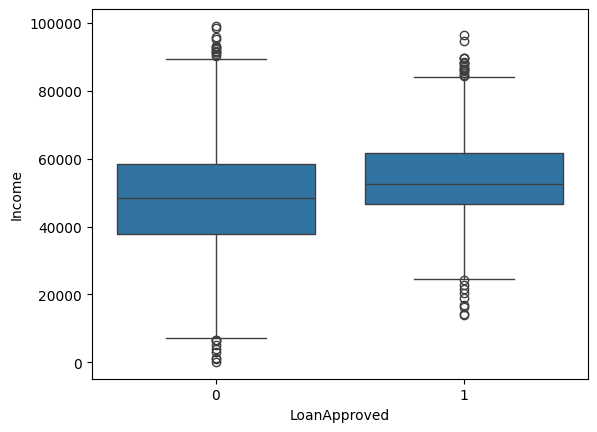

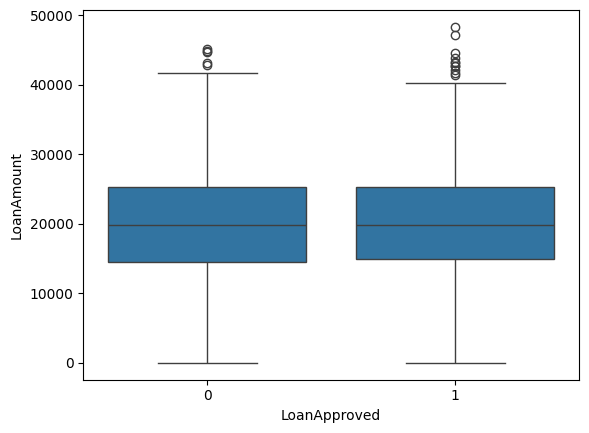

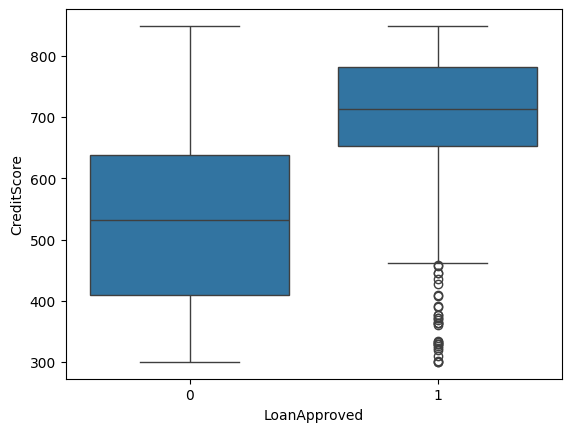

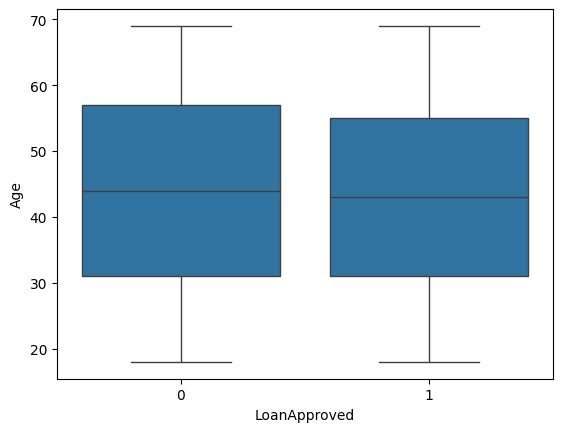

In [21]:
sns.boxplot(x='LoanApproved', y='Income', data=df)
plt.show()

sns.boxplot(x='LoanApproved', y='LoanAmount', data=df)
plt.show()

sns.boxplot(x='LoanApproved', y='CreditScore', data=df)
plt.show()

sns.boxplot(x='LoanApproved', y='Age', data=df)
plt.show()

### Categorical Feature Relationship with Loan Approval

Categorical variables are analyzed against the target variable to observe whether approval patterns differ across categories.

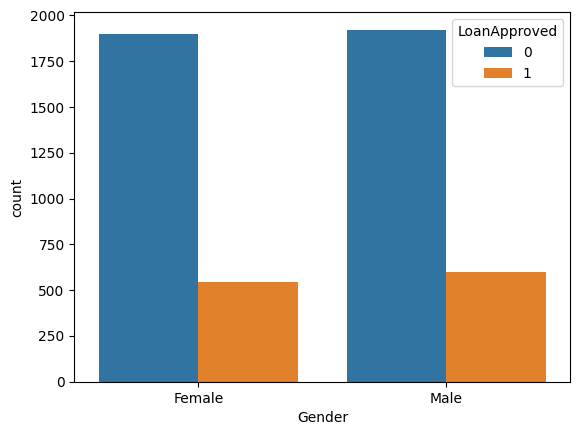

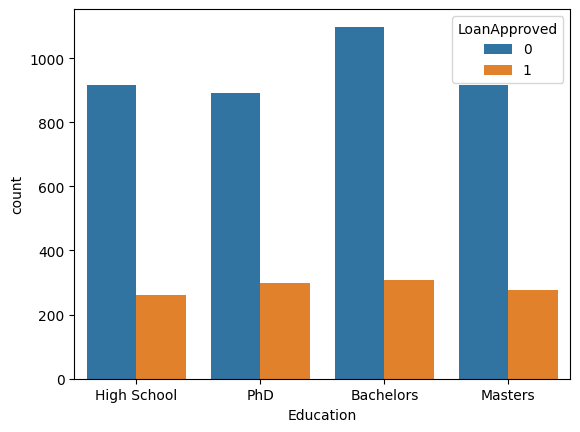

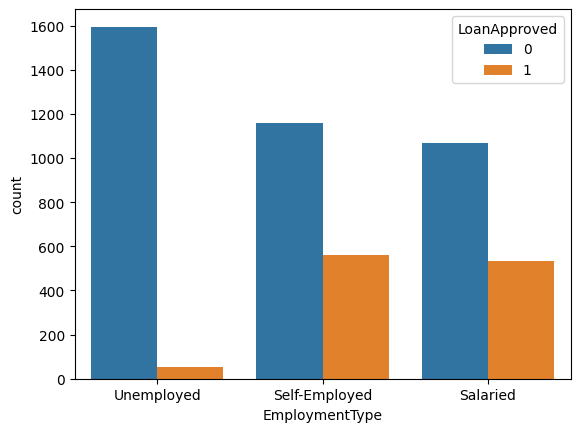

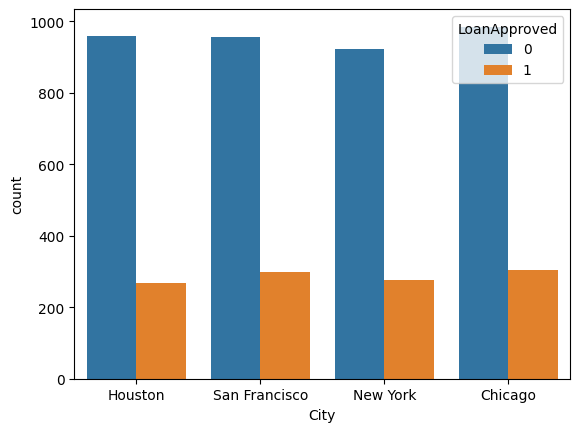

In [22]:
sns.countplot(x='Gender', hue='LoanApproved', data=df)
plt.show()

sns.countplot(x='Education', hue='LoanApproved', data=df)
plt.show()

sns.countplot(x='EmploymentType', hue='LoanApproved', data=df)
plt.show()

sns.countplot(x='City', hue='LoanApproved', data=df)
plt.show()

### Manual Inspection of Extreme Financial Records

Extremely high or unusual income values are manually inspected to determine whether they are legitimate observations or influential outliers.

In [24]:
print(df[df['Income'] > 100000])

Empty DataFrame
Columns: [Age, Income, LoanAmount, CreditScore, YearsExperience, Gender, Education, City, EmploymentType, LoanApproved]
Index: []


### Correlation Analysis Between Numerical Features

A correlation heatmap is generated to identify positive or negative linear relationships among numerical variables.

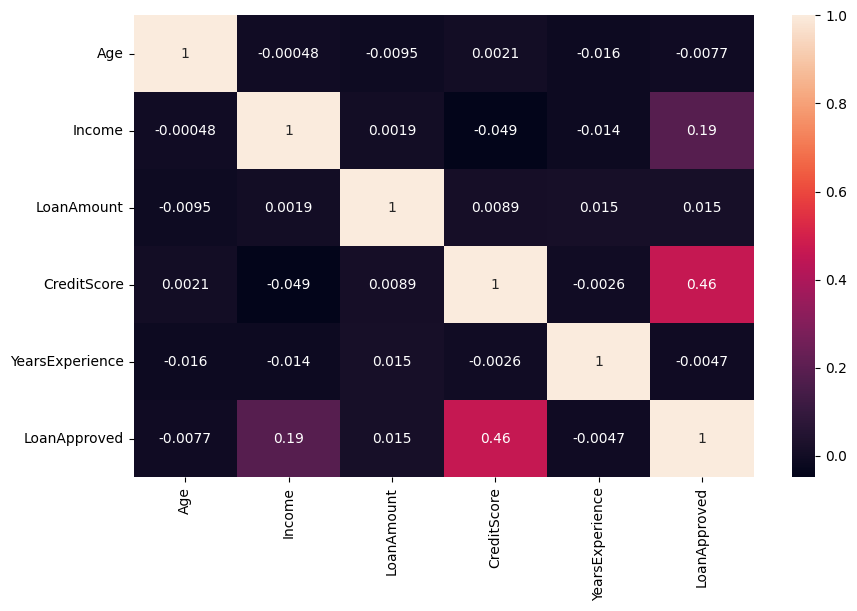

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True)
plt.show()